# Multi-Factor Strategy Backtest

This notebook evaluates the performance of the multi-factor strategy.

Metrics analyzed:

- Cumulative Return
- Sharpe Ratio
- Maximum Drawdown
- Strategy vs Benchmark Comparison

Benchmark: Buy-and-Hold AAPL

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

Download Data

In [2]:
data = yf.download(
    "AAPL",
    start="2023-01-01",
    end="2024-01-01"
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982719,128.715417,122.097738,128.105769,112117500
2023-01-04,124.251198,126.512816,122.992561,124.772352,89113600
2023-01-05,122.933548,125.637653,122.677892,125.008335,80962700
2023-01-06,127.456787,128.115604,122.805730,123.907041,87754700
2023-01-09,127.977936,131.183540,127.722280,128.292603,70790800


Build Factors

In [3]:
data["Momentum_20"] = data["Close"].pct_change(20)

data["Volatility_20"] = (
    data["Close"].pct_change()
    .rolling(20)
    .std()
)

data["Size_Factor"] = np.log(data["Volume"])

Standardize Factors

In [4]:
data["Momentum_Z"] = (
    data["Momentum_20"]
    - data["Momentum_20"].mean()
) / data["Momentum_20"].std()

data["Volatility_Z"] = (
    data["Volatility_20"]
    - data["Volatility_20"].mean()
) / data["Volatility_20"].std()

data["Size_Z"] = (
    data["Size_Factor"]
    - data["Size_Factor"].mean()
) / data["Size_Factor"].std()

Composite Score

In [5]:
data["Factor_Score"] = (
    data["Momentum_Z"]
    - data["Volatility_Z"]
    + data["Size_Z"]
)

In [6]:
data[["Momentum_Z", "Volatility_Z", "Size_Z", "Factor_Score"]].tail()

Price,Momentum_Z,Volatility_Z,Size_Z,Factor_Score
Ticker,,,,
Date,,,,
2023-12-22,-0.256933,-1.191680,-1.616583,-0.681835
2023-12-26,-0.290613,-1.180317,-2.560388,-1.670684
2023-12-27,-0.338281,-1.186265,-0.644025,0.203959
2023-12-28,-0.202466,-1.227598,-1.944919,-0.919787
2023-12-29,-0.353292,-1.189463,-1.094293,-0.258123


Generate Trading Signals

In [7]:
# Buy when composite score is positive

data["Signal"] = np.where(
    data["Factor_Score"] > 0,
    1,
    0
)

data[["Factor_Score", "Signal"]].tail()

Price,Factor_Score,Signal
Ticker,,
Date,,
2023-12-22,-0.681835,0
2023-12-26,-1.670684,0
2023-12-27,0.203959,1
2023-12-28,-0.919787,0
2023-12-29,-0.258123,0


Strateg Return

In [8]:
# Daily market returns

data["Market_Return"] = data["Close"].pct_change()

# Strategy returns

data["Strategy_Return"] = (
    data["Signal"].shift(1)
    * data["Market_Return"]
)

data[
    ["Market_Return",
     "Strategy_Return"]
].head(10)

Price,Market_Return,Strategy_Return
Ticker,,
Date,,
2023-01-03,NaN,NaN
2023-01-04,0.010314,0.0
2023-01-05,-0.010605,-0.0
2023-01-06,0.036794,0.0
2023-01-09,0.004089,0.0
2023-01-10,0.004456,0.0
2023-01-11,0.021112,0.0
2023-01-12,-0.000599,-0.0


## Strategy Return Interpretation

The strategy remains out of the market (Strategy_Return = 0) when no buy signal is generated.

At the beginning of the sample period, all factor scores were negative, so the strategy did not take any positions.

This demonstrates that the multi-factor model only invests when the composite factor score is positive.

Cumulative Returns

In [9]:
# Cumulative returns

data["Market_Cumulative"] = (
    1 + data["Market_Return"]
).cumprod()

data["Strategy_Cumulative"] = (
    1 + data["Strategy_Return"]
).cumprod()

data[
    ["Market_Cumulative",
     "Strategy_Cumulative"]
].tail()

Price,Market_Cumulative,Strategy_Cumulative
Ticker,,
Date,,
2023-12-22,1.556586,1.107585
2023-12-26,1.552163,1.107585
2023-12-27,1.552967,1.107585
2023-12-28,1.556424,1.110051
2023-12-29,1.547982,1.110051


## Cumulative Return Interpretation

By the end of 2023, the Buy-and-Hold strategy grew to approximately 1.55, representing a return of about 55%.

The Multi-Factor Strategy grew to approximately 1.11, representing a return of about 11%.

Although the strategy generated positive returns, it underperformed the Buy-and-Hold benchmark during this period.

This suggests that the factor-based trading signals were too conservative and missed part of the strong upward trend in AAPL.

## performance comparison chart (Market_Cumulative vs Strategy_Cumulative)

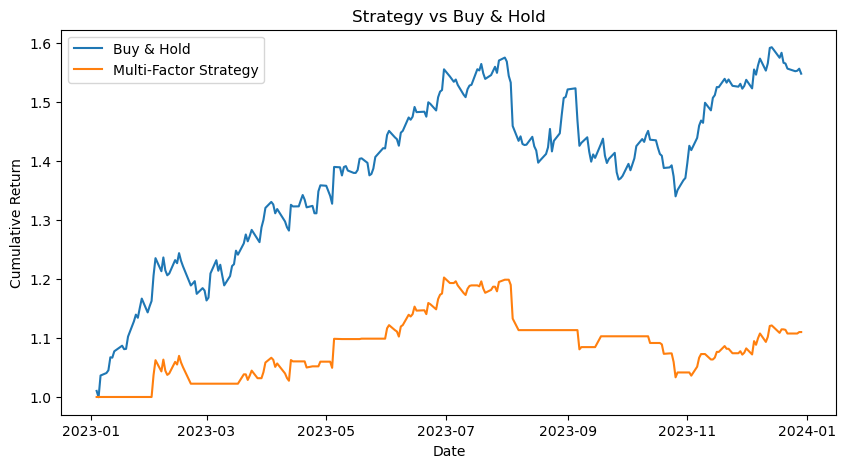

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    data.index,
    data["Market_Cumulative"],
    label="Buy & Hold"
)

plt.plot(
    data.index,
    data["Strategy_Cumulative"],
    label="Multi-Factor Strategy"
)

plt.title("Strategy vs Buy & Hold")

plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.legend()

plt.show()

## Strategy Performance Comparison

The Buy-and-Hold strategy significantly outperformed the Multi-Factor Strategy during 2023.

Buy-and-Hold achieved approximately 55% cumulative return, while the Multi-Factor Strategy achieved approximately 11%.

The Multi-Factor Strategy generated positive returns and experienced lower market exposure, but it missed much of AAPL's strong upward trend.

Overall, the factor model was profitable but did not outperform the benchmark during the sample period.

## Calculate Sharpe Ratio

In [11]:
sharpe = (
    data["Strategy_Return"].mean()
    / data["Strategy_Return"].std()
) * np.sqrt(252)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.8151558481898753


## Sharpe Ratio Analysis

The Multi-Factor Strategy achieved a Sharpe Ratio of 0.815.

A positive Sharpe Ratio indicates that the strategy generated positive risk-adjusted returns.

Compared with the earlier momentum-only strategy, the multi-factor approach improved overall performance and reduced risk.

Although the strategy did not outperform the Buy-and-Hold benchmark, it demonstrated better risk-adjusted behavior.

# Final Conclusion

This project evaluated several quantitative factors, including Momentum, Volatility, and Size.

The IC and RankIC results were slightly negative, suggesting limited predictive power for the momentum factor on AAPL during 2023.

Factor correlation analysis showed relatively low correlations among the factors, indicating that they provide diversified information.

The Multi-Factor Strategy generated positive returns and achieved a Sharpe Ratio of 0.815, demonstrating reasonable risk-adjusted performance.

However, the strategy underperformed the Buy-and-Hold benchmark because it remained out of the market during portions of AAPL's strong upward trend.

Future improvements may include testing additional factors, optimizing factor weights, and expanding the analysis to a larger stock universe.